# Базовые компоненты нейронных сетей

**Выполнила**: Смирнова Анастасия

## Настройка окружения

In [ ]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    recall_score
)
import seaborn as sns
import random
import warnings
import tqdm
warnings.filterwarnings('ignore')

# Фиксируем seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Задача 1. Линейная функция и нейрон

### Постановка задачи

Обучить простейший линейный классификатор (один нейрон без скрытых слоев) на двумерных данных.

**Теоретический минимум:**
- Линейный нейрон: $y = w_1 x_1 + w_2 x_2 + b$
- Сигмоида для бинарной классификации: $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Бинарная кросс-энтропия: $L = -\frac{1}{N} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$


### Генерация данных
Так как `make_moons` больше подходит для генерации нелинейных данных, реализуем собственный класс RandomDataGen для генерации двумерных случайно разделимых данных.

In [ ]:
class RandomDataGen():
    """
    Класс для генерации случайных двумерных линейно разделимых данных

    Параметры:
        n_points : int
            Количество наблюдений в каждом классе
        random_state: int
            seed для обеспечения воспроизводимости
        noise: float
            случайный шум

    Атрибуты:
        X : np.array размером (2*n_points, 2)
            Двумерный массив признаков
        y : np.array размером (2*n_points, 1)
            Массив меток (0 для первого класса, 1 для второго)
    """
    def __init__(self, n_points: int, random_state: int, noise: float):
        self.n_points = n_points
        self.random_state = random_state
        self.noise = noise

    def generate_data(self):
        rng = np.random.RandomState(self.random_state)
        bias = rng.randint(low=1, high=5, size=2)

        X_neg = np.random.randn(self.n_points, 2) * self.noise + bias
        y_neg = np.zeros(self.n_points)

        X_pos = np.random.randn(self.n_points, 2) * self.noise + (-bias)
        y_pos = np.ones(self.n_points)

        X = np.vstack([X_neg, X_pos])
        y = np.hstack([y_neg, y_pos]).reshape(-1, 1)

        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]

        return X, y

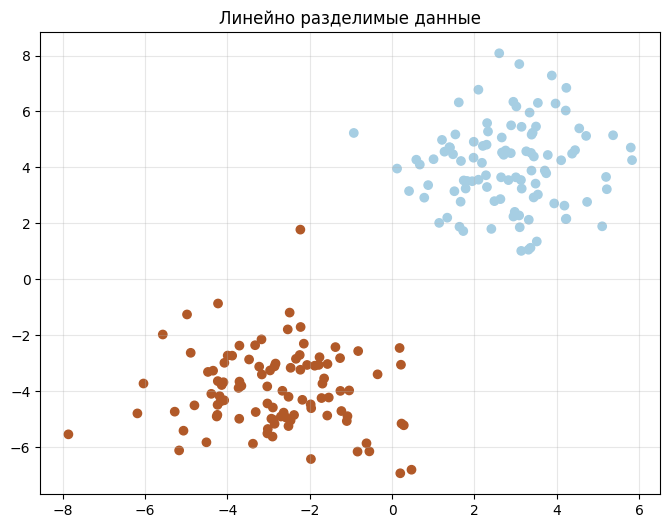

In [ ]:
# Генерируем данные
generator = RandomDataGen(100, SEED, 1.5)

X, y = generator.generate_data()

# Визуализируем исходные данные
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Paired')
plt.title("Линейно разделимые данные")
plt.grid(True, alpha=0.3)
plt.show()

### Реализация класса для бинарной классификации

Реализуем собственный класс BinaryClassificator, унаследованный от `torch.nn.Module`

In [ ]:
class BinaryClassificator(torch.nn.Module):
    """
    Класс для бинарной классификации без скрытых слоев
    Дочерний от torch.nn.Module

    Параметры:
        input_size: int
            Размерность входных данных

    Атрибуты:
       fc : torch.nn.Linear
            Линейный слой с выходной размерностью 1

    Методы:
        forward()
            Прямой проход через модель
        predict()
            Делает предсказание
    """
    def __init__(self, input_size):
        super(BinaryClassificator, self).__init__()

        # Единственный слой
        self.fc = torch.nn.Linear(input_size, 1)

    def forward(self, x):
        return self.fc(x)

    def predict(self, x, threshold=0.5):
        """
        Делает предсказание

        Параметры:
            x: torch.Tensor
               Тензор со значениями признаков

            threshold: float
                Порог классификации. По умолчанию: 0.5
        Возвращает:
            y_pred: torch.Tensor
                Тензор с предсказаниями (0, 1)
            y_proba: torch.Tensor
                Тензор со значениями вероятности
            weights: torch. Tensor
                Тензор с весами
            bias: torch. Tensor
                Тензор с смещением
        """
        with torch.no_grad(): # Не вычисляем градиенты
            logits = self(x)

            # Пропускаем через сигмоиду
            y_proba = torch.sigmoid(logits)
            y_pred = (y_proba > threshold).float()

            # Получаем веса
            weights = self.fc.weight.detach().numpy()[0]

            # Получаем bias
            bias = self.fc.bias.detach().numpy()[0]

            return y_pred, y_proba, weights, bias

### Построение модели и оценка качества

In [ ]:
# Создаем модель
bn_classificator = BinaryClassificator(input_size=2)

# Разбиваем данные на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Преобразуем данные в тензоры
X_torch_train = torch.FloatTensor(X_train)
y_torch_train = torch.FloatTensor(y_train)

X_torch_test = torch.FloatTensor(X_test)
y_torch_test = torch.FloatTensor(y_test)

# Создаем оптимизатор
optimizer = torch.optim.Adam(bn_classificator.parameters(), lr=0.01)

# Создаем функцию потерь
loss_func = torch.nn.BCEWithLogitsLoss()

# Обучаем модель
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = bn_classificator(X_torch_train)
    loss_val = loss_func(y_pred, y_torch_train)
    loss_val.backward()
    optimizer.step()

# Делаем предсказание
y_pred, y_proba, weights, bias = bn_classificator.predict(X_torch_test)

In [ ]:
# Получаем accuracy
ac_score = accuracy_score(y_torch_test, y_pred)

print(f"Accuracy: {ac_score:.2f}")

Accuracy: 1.00


Доля правильных ответов нашей модели равняется 1.
Это значит, что модель безошибочно предсказала метки для всех классов.

Убедимся в этом, построив график с линией разделения классов.

Поскольку исходное уравнение имеет вид:
$$y = w_1 x_1 + w_2 x_2 + b$$

Где:
- $y$ - предсказание модели (логит)
- $w_1, w_2$: веса(коэффициенты)
- $b$: bias(смещение)
- $x_1, x_2$ — признаки (координаты точек)

Если $y$ > 0 после прохождения через сигмоиду значение будет > установленного порога классификации. Объект будет отнесен к классу 1.
Если $y$ < 0 после прохождения через сигмоиду значение будет < установленного порога классификации. Объект будет отнесен к классу 0.

Для получения разделяющей линии нам необходимо получить все значения логитов, равные 0. Для этого нам нужно:

1. Выразить $x_2$ из уравнения $w_1 x_1 + w_2 x_2 + b = 0$:

$$x_2= (\frac{(-w_1x_1 - b)}{w_2})$$

2. Для $x_1$ взять все точки от минимальной до максимальной
3. Для $x_2$ вычислить точки согласно полученному уравнению
4. Построить линию, отметив точки пересечения для соответствующих пар $x_1$, $x_2$.

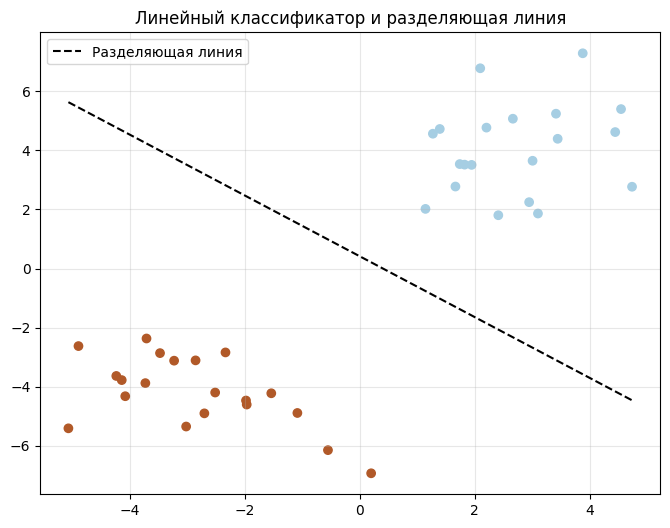

In [ ]:
# Создаем точки для линии
x1_line = np.linspace(X_torch_test[:, 0].min(), X_torch_test[:, 0].max(), 100)
x2_line = (-weights[0] * x1_line - bias) / weights[1]

# Строим график с разделяющей линией
plt.figure(figsize=(8, 6))
plt.scatter(X_torch_test[:, 0], X_torch_test[:, 1], c=y_torch_test, cmap='Paired')
plt.plot(x1_line, x2_line, 'k--', label='Разделяющая линия')
plt.title('Линейный классификатор и разделяющая линия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На графике видно, что разделяющая линия четко разделяет два противоположных класса. Это совпадает с полученным значением accuracy.

## Задача 2. Активационные функции

### Постановка задачи

Реализовать три активационные функции вручную и визуализировать их.

**Теоретический минимум:**
- ReLU: $f(x) = \max(0, x)$
- Sigmoid: $f(x) = \frac{1}{1 + e^{-x}}$
- Tanh: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

### Реализация функций
Рассмотрим три функции активации: RELu, Sigmoid и Tanh.
Реализуем функцию ReLU.

Функция ReLU имеет вид:

$$f(x) = \max(0, x)$$

Может принимать два возможных значения:

- 0, если x <= 0;
- x, если x > 0.

Соответственно:

- При $x \rightarrow -\infty$, $f(x)\rightarrow 0$;
- При $x \rightarrow \infty$, $f(x)\rightarrow x$ (линейный рост).

In [ ]:
def ReLU(x):
    """
    Ручная реализация функции ReLu

    Возвращает:
       0, если x <= 0
       x, если x > 0
    """
    return np.maximum(0,x)

Реализуем функцию сигмоиды.

Функция сигмоиды имеет вид:

$$f(x) = \frac{1}{1 + e^{-x}}$$

Может принимать непрерывное значение на интервале (0, 1).
Используется в задачах классификации для вероятностной интепретации логита.

- При $x \rightarrow -\infty$, $f(x)\rightarrow 0$;
- При $x \rightarrow \infty$, $f(x)\rightarrow 1$.

In [ ]:
def sigmoid(x):
    """
    Ручная реализация сигмоиды

    Возвращает:
        значение в интервале (0, 1), вероятностная интерпретация логита
    """
    return (1+np.exp(-x))**-1

Реалиузем функцию гиперболического тангенса.
Фукнция имеет вид:

$$f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Может принимать непрерывное значение на интервале (-1,1).

- При $x \rightarrow -\infty$, $f(x)\rightarrow -1$;
- При $x \rightarrow \infty$, $f(x)\rightarrow 1$.

In [ ]:
def tanh(x):
    """
    Ручная реализация гиперболического тангенса

    Возвращает:
        значение в интервале от -1 до 1
    """
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

### Построение графиков и оценка
Вычислим значения каждой функции для интервала $x \in [-5, 5]$ и построим графики.

In [ ]:
# Генерируем 100 значений x на интервале [-5, 5]
x = np.linspace(-5, 5, 100)

In [ ]:
# Считаем значения каждой функции
f_x_relu = ReLU(x)
f_x_sigmoid = sigmoid(x)
f_x_tanh = tanh(x)

funcs_lst = [f_x_relu, f_x_sigmoid, f_x_tanh]

In [ ]:
def plot_activations(x, activations, names) -> None:
    """
    Строит графики функций активации ReLU, Sigmoid, Tanh.

    Параметры:
    x : np.array
        Массив со значениями x
    activations : list of np.array
        Список массивов со значениями f(x)
    names : list of str
        Список с названиями функций активации
    """
    plt.figure(figsize=(12, 4))

    asymptotes = {
        'ReLU': {'left': 'f(x)→0', 'right': 'f(x)→x'},
        'Sigmoid': {'left': 'f(x)→0', 'right': 'f(x)→1'},
        'Tanh': {'left': 'f(x)→-1', 'right': 'f(x)→1'}
    }

    for i, (y, name) in enumerate(zip(activations, names)):
        plt.subplot(1, 3, i + 1)
        plt.plot(x, y, linewidth=2, label=name)
        plt.title(
            f'{name}\nДиапазон: [{y.min():.1f}, {y.max():.1f}]',
            fontsize=12
        )
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

        # Добавляем информацию об асимптотах
        if name == 'Sigmoid':
            plt.text(
                4, 0.9, f'{asymptotes[name]["right"]}',
                fontsize=9, ha='left', color='darkgreen'
            )
            plt.text(
                -5, 0.1, f'{asymptotes[name]["left"]}',
                fontsize=9, ha='left', color='darkgreen'
            )
        elif name == 'Tanh':
            plt.text(
                4, 0.85, f'{asymptotes[name]["right"]}',
                fontsize=9, ha='left', color='darkgreen'
            )
            plt.text(
                -5, -0.9, f'{asymptotes[name]["left"]}',
                fontsize=9, ha='left', color='darkgreen'
            )
        elif name == 'ReLU':
            plt.text(
                4, 5, f'{asymptotes[name]["right"]}',
                fontsize=9, ha='left', color='darkgreen'
            )
            plt.text(
                -5, 0.2, f'{asymptotes[name]["left"]}',
                fontsize=9, ha='left', color='darkgreen'
            )

    plt.suptitle(
        'Функции активации и их асимптоты',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

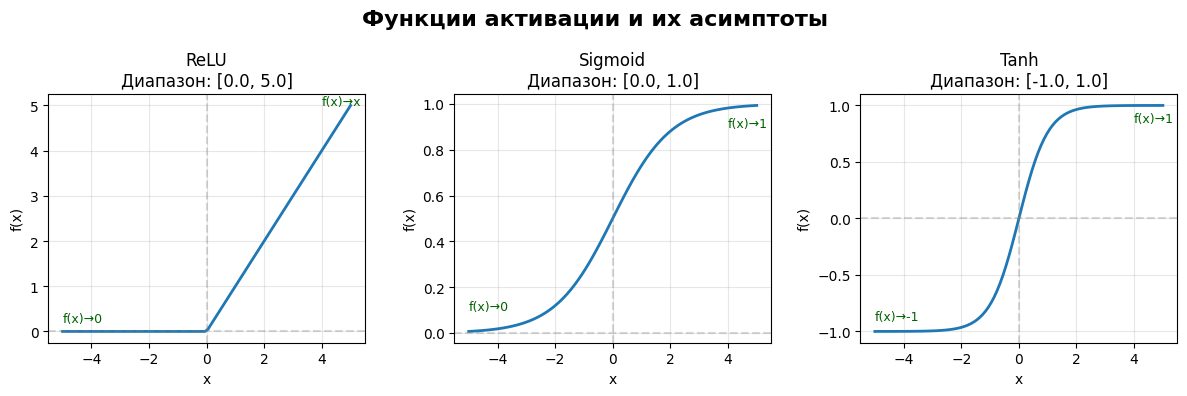

In [ ]:
# Визуализируем
plot_activations(x, funcs_lst, ['ReLU','Sigmoid','Tanh'])

Из-за своей простоты ReLU является самой популярной функцией активации для скрытых слоев, так как она помогает бороться с проблемой затухающих градиентов.

ReLU помогает бороться с затуханием градиентов благодрая тому, что для всех положительных входов её производная равна 1, а не стремится к нулю, как у Sigmoid или Tanh.

Тем не менее сигмоида и гиперболический тангенс могут быть эффективны в простых нейросетях, где нет мало скрытых слоев (например, сигмоида эффективна в задаче бинарной классификации, чтобы было выявлено на примере задачи 1).

## Задача 3. Forward pass через сеть

### Постановка задачи

Реализовать forward pass для полносвязной сети вручную с NumPy.

**Теоретический минимум:**
- Layer: $z = Wx + b$
- Network: $h = \sigma(z) = \sigma(W_1 x + b_1)$, затем $\hat{y} = W_2 h + b_2$

### Реализуем forward pass

Реализуем в ручную прямой проход для сети вида:

$$Input (2) → Hidden (8, ReLU) → Output (1, Sigmoid)$$

Где слой имеет вид:
- Layer: $z = Wx + b$

Распишем по действиям:
- $h = ReLU(W1x + b1)$ - результат после скрытого слоя;
- $\hat{y} = \sigma(W_2 h + b_2)$ - конечный результат.

Где:

- $ReLU$ - функция активации ReLU;
- $\sigma$ - функция сигмоиды;
- $W1, W2$ - матрицы весов;
- $b1, b2$ - векторы смещений.


In [ ]:
def manual_fw_pass(x, params_one, params_two):
    """
    Ручная реализация прямого прохода
    для нейросети
    Input (2) → Hidden (8, ReLU) → Output (1, Sigmoid)

    Параметры:
        x: np.array размером (n, 2)
            Исходный батч
        params_one: list
            Список со значениями W1 и b1
        params_two
            Список со значениями W2 и b2

    Возвращает:
        prediction: np.array
            Массив с предсказаниями
    """
    print(f"Размер исходного батча: {x.shape}")
    h = ReLU(np.dot(x, params_one[0]) + params_one[1])
    print(f"Размер батча, после прохождения скрытого слоя: {h.shape}")

    y_hat = sigmoid(np.dot(h, params_two[0]) + params_two[1])
    print(f"Размер батча на выходе: {y_hat.shape}")

    return y_hat

### Реализуем сеть

In [ ]:
rng = np.random.default_rng(SEED)

# Создаем случайный батч
X = rng.normal(size=(32, 2))

# Инициализируем веса и bias
W1 = rng.normal(size=(2, 8))
b1 = rng.normal(size=(8,))
params_one = [W1, b1]

W2 = rng.normal(size=(8, 1))
b2 = rng.normal(size=(1,))
params_two = [W2, b2]

# Forward pass
prediction = manual_fw_pass(X, params_one, params_two)

# Проверка размерностей
print("Пример выхода (первые 5 примеров):")
print(prediction[:5])

Размер исходного батча: (32, 2)
Размер батча, после прохождения скрытого слоя: (32, 8)
Размер батча на выходе: (32, 1)
Пример выхода (первые 5 примеров):
[[0.36348967]
 [0.24555821]
 [0.0009177 ]
 [0.2783858 ]
 [0.23369054]]


## Задача 4. Матрично-векторные операции

### Постановка задачи

Разобраться с broadcasting в NumPy и визуализировать результаты.

**Теоретический минимум:**
- Broadcasting — автоматическое расширение размеров массивов.
- Важно для батчевых операций.

Инициализиурем функцию, которая выполнит преобразование вида:

$$z = X \cdot w + b$$

In [ ]:
def calculate(X, w, b):
    """
    Вычисляет значение слоя
    z = Xw + b

    Параметры:
        X (np.array):
            Исходный батч
        w (np.array):
            Вектор весов
        b (np.arrray):
            Вектор bias
    Возвращает:
        z (np.array):
            Вектор после преобразований
    """
    z = np.dot(X, w) + b
    print(f"Размерность после broadcasting: {z.shape}")
    return z

Изучим работу broadcasting на примере случайно инициализированного батча, вектора весов и bias.

In [ ]:
rng = np.random.default_rng(SEED)

# Создаем случайный батч
X = rng.normal(size=(10, 5))

# Инициализируем вектор весов и bias
w = rng.normal(size=(5,))
b = rng.normal(size=(1,))

In [ ]:
calculate(X, w, b)

Размерность после broadcasting: (10,)


array([-1.68379014, -0.06722495, -0.57008314,  0.48538193, -2.65274885,
       -1.27174007,  0.44056632,  0.79737701,  0.75954848, -0.60015803])

На вход было подано:

- $X$ - исходный батч размером (10, 5), представляющий собой матрицу из 10 строк и пяти столбцов;
- $w$ - вектор весов размером (5,) - состоящий из пяти координат;
- $b$ - вектор bias размером (1,) - состоящий из одного скаляра.

Благодаря механизму broadcasting, реализованному в NumPy было выполнено следующее:

- После выполнения умножения $X*w$ был получен вектор размером (10,)скаляр $b$ автоматически растягивается до размера (10,), что позволяет к каждому элементу $X*w$ добавить $b$ и получить на выходе также вектор (одномерный массив) размером (10,), а не столбец (двумерный массив) размером (10, 1).

Это крайне важно для дальнейших вычислений, так как неправильный размер может привести к ошибкам в дальнейших вычислениях, если ожидается одномерный массив.

Наглядно продемонстируем ниже.

In [ ]:
# Проверяем, что произойдет, если задать неверные размерности
w_wrong = w.reshape(5, 1)
calculate(X, w_wrong, b)

Размерность после broadcasting: (10, 1)


array([[-1.68379014],
       [-0.06722495],
       [-0.57008314],
       [ 0.48538193],
       [-2.65274885],
       [-1.27174007],
       [ 0.44056632],
       [ 0.79737701],
       [ 0.75954848],
       [-0.60015803]])

В данном примере мы инициализировали $w$ не как одномерный вектор, а как двумерный столбец.

Broadcasting также сработал и numpy автоматически преобразовал $b$ в столбец (1,1). На выходе мы получили не вектор, а столбец размером (10,1). В случае если на следующем шаге ожидается вектор, а не столбец возникнет ошибка в вычислениях.

Таким образом, крайне важно верно задавать исходную размерность данных.

## Задача 5. Решение задачи XOR

### Постановка задачи

XOR не разделим линейно. Построить сеть, которая это решает.

**Теоретический минимум:**
- XOR требует скрытого слоя с хотя бы 2—3 нейронами.
- Геометрически: скрытый слой преобразует пространство, делая классы линейно разделимыми.

### Класс XOR
Создадим класс для решения задачи XOR.
Класс будет воплощать сеть с одним скрытым слоем вида:

$$Input(2) → Hidden(n, ReLU) → Output(1, Sigmoid)$$

Где:

- $n$ - количество нейронов в скрытом слое.

In [ ]:
class XorSolver(torch.nn.Module):
    """
    Класс для решения задачи XOR

    Параметры:
        n_hidden_neurons: int
            Количество скрытых слоев

    Атрибуты:
       fc1: torch.nn.Linear
            Линейный слой с выходной размерностью n_hidden_neurons
       ac1: torch.nn.ReLU
            Функция активации скрытого слоя
       fc2: torch.nn.Linear
            Линейный слой с выходной размерностью 1
       ac2: torch.nn.Sigmoid
            Функция активации выходного слоя

    Методы:
        forward()
            Прямой проход через модель

    """
    def __init__(self, n_hidden_neurons):
        super(XorSolver, self).__init__()

        self.fc1 = torch.nn.Linear(2, n_hidden_neurons)
        self.act1 = torch.nn.ReLU()

        self.fc2 = torch.nn.Linear(n_hidden_neurons, 1)
        self.act2 = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)

        return x

    def predict(self, x, threshold=0.5):
        """
        Делает предсказание

        Параметры:
            x: torch.Tensor
               Тензор координатами точек

            threshold: float
                Порог классификации. По умолчанию: 0.5
        Возвращает:
            y_pred: torch.Tensor
                Тензор с предсказаниями (0, 1)
            y_proba: torch.Tensor
                Тензор со значениями вероятности
        """
        with torch.no_grad(): # Не вычисляем градиенты
            y_proba = self(x)
            y_pred = (y_proba > threshold).float()

            return y_pred, y_proba

### Подбор оптимального `lr`


Инициализируем тензор X, состоящий из точек:
- Точка 1: $(x_1, x_2) = (0, 0)$
- Точка 2: $(x_1, x_2) = (0, 1)$
- Точка 3: $(x_1, x_2) = (1, 0)$
- Точка 4: $(x_1, x_2) = (1, 1)$

И тензор y, состоящий из меток:
- $y_1 = 0$
- $y_2 = 1$
- $y_3 = 1$
- $y_4 = 0$

Тип данных укажем как float для совместимости типов с вычисляемыми весами и градиентами.

In [ ]:
# Создаем тензоры X, y
X_xor = torch.FloatTensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = torch.FloatTensor([
    [0],
    [1],
    [1],
    [0]
])

Подберем оптимальное значение `lr` в диапазоне от 0.1 до 0.5 для сети, содержащей четыре скрытых нейрона при обучении в течение 1000 эпох.

In [ ]:
# Задаем диапазон возможных lr
rates = np.arange(0.1, 0.5, 0.01)

In [ ]:
def find_best_lr(X, y, rates):
    """
    Подбирает значение lr,
    при котором достигается максимальное значение accuracy_score и минимальный loss
    для сети вида Input(2) → Hidden(4, ReLU) → Output(1, Sigmoid)

    Параметры:
        X: torch.tensor
            Тензор, содержащий две координаты точек
        y: torch.tesor
           Тензор, содержащих метки классов
        rates: np.array
            Массив, содержащий различные значения lr

    Возвращает:
        best_lr: float
            Значение lr, при котором достигается максимальный accuracy_score
    """
    best_accuracy = 0.0
    best_lr = None
    best_loss = float("inf")

    # В цикле для каждого lr
    for r in tqdm.tqdm(rates):

        # Создаем модель с четырьмя скрытыми нейронами
        solver = XorSolver(n_hidden_neurons=4)

        loss_func = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(solver.parameters(), lr=r)

        # Обучаем Adam в течение 1000 эпох
        for epoch in range(1000):
            optimizer.zero_grad()
            y_pred = solver(X)
            loss = loss_func(y_pred, y)
            loss.backward()
            optimizer.step()

        # Оцениваем accuracy и loss
        y_pred_class, y_proba = solver.predict(X)
        acc = accuracy_score(y.numpy(), y_pred_class.numpy())
        loss = loss_func(solver(X), y)

        print(f"lr = {r:.2f}, Accuracy = {acc:.4f}, Loss = {loss:.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_lr = r
            best_loss = loss
        elif acc == best_accuracy and loss < best_loss:
            best_lr = r
            best_loss = loss

    print(f"Лучший lr: {best_lr: .2f}, Accuracy: {best_accuracy:.4f}, Loss: {best_loss}")
    return best_lr

In [ ]:
# Подбираем лучший для нашей сети lr
lr = find_best_lr(X_xor, y_xor, rates)

  2%|▎         | 1/40 [00:02<01:29,  2.29s/it]

lr = 0.10, Accuracy = 1.0000, Loss = 0.0000


  5%|▌         | 2/40 [00:04<01:32,  2.43s/it]

lr = 0.11, Accuracy = 0.7500, Loss = 0.4774


  8%|▊         | 3/40 [00:06<01:16,  2.05s/it]

...

lr = 0.47, Accuracy = 0.7500, Loss = 0.4774


 98%|█████████▊| 39/40 [00:44<00:00,  1.23it/s]

lr = 0.48, Accuracy = 1.0000, Loss = 0.0000


100%|██████████| 40/40 [00:45<00:00,  1.13s/it]

lr = 0.49, Accuracy = 0.7500, Loss = 0.4774
Лучший lr:  0.23, Accuracy: 1.0000, Loss: 3.5668786040332634e-06


### Обучение и визаулизация

Обучим нашу сеть с оптимальным `lr` в течение 1000 эпох, используя Adam, и визуализируем результат.

In [ ]:
# Инициализируем и обучаем модель с лучшими lr
solver = XorSolver(4)
loss_func = torch.nn.BCELoss()
optimizer = torch.optim.Adam(solver.parameters(), lr=lr)

# Обучаем Adam в течение 1000 эпох
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = solver(X_xor)
    loss = loss_func(y_pred, y_xor)
    loss.backward()
    optimizer.step()

# Оцениваем accuracy и loss
y_pred_class, y_proba = solver.predict(X_xor)
loss = loss_func(solver(X_xor), y_xor)
acc = accuracy_score(y_xor.numpy(), y_pred_class.numpy())

print(f"lr = {lr:.2f}, Accuracy = {acc:.4f}, Loss = {loss:.4f}")

lr = 0.23, Accuracy = 1.0000, Loss = 0.0000


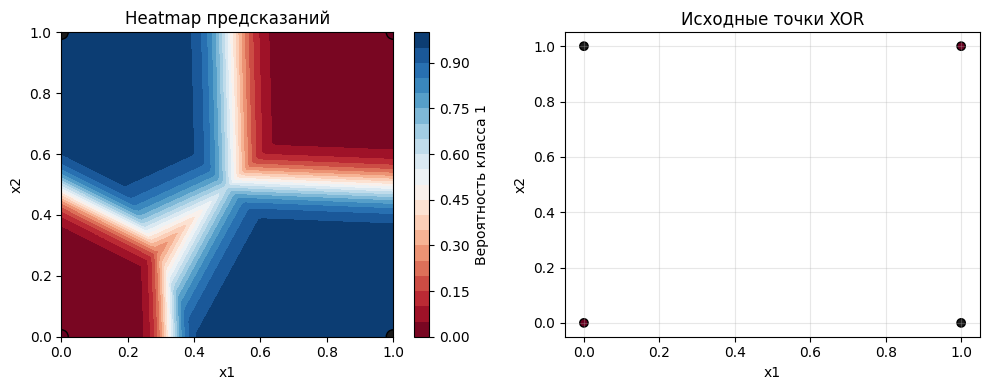

In [ ]:
# Визуализируем
plt.figure(figsize=(10, 4))

# Heatmap
# Создаем сетку точек для heatmap
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

# Получаем предсказания для всех точек сетки
_, grid_probs = solver.predict(grid)
grid_probs = grid_probs.numpy().reshape(xx.shape)

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, grid_probs, levels=20, cmap='RdBu')
plt.colorbar(label='Вероятность класса 1')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor,
            edgecolors='k', s=100, cmap='RdGy')
plt.title('Heatmap предсказаний')
plt.xlabel('x1')
plt.ylabel('x2')

# Исходные точки
plt.subplot(1, 2, 2)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor,
            cmap='RdGy', edgecolors='k')

plt.title('Исходные точки XOR')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Наша модель верно предсказывает метки для всех четырех точек.
Таким образом, задача XOR решаема с использованием оптимизатора Adam, обучении в течение 1000 эпох при lr = 0.23. Значение loss при заданных параметрах минимальное, а accuracy = 1 (что соответствует полностью верной классификации).

## Задача 6. Анализ трансформации признаков

### Постановка задачи

Визуализировать, как скрытый слой преобразует исходное пространство.

Оценим, как изменилось взаимное расположние классов для задачи XOR после прохождения активации скрытого слоя.

После прохождения скрытого слоя данные отображаются в четырехмерном пространстве. Поскольку визуализировать пространство такой размерности невозможно, покажем 2D проекцию первых двух нейронов скрытого слоя.

Затем обучим на полученных данных простой линейный классификатор, чтобы оценить линейную разделимость данных, полученных от двух нейронов.

In [ ]:
# Получаем результат активации скрытого слоя
hidden_layer = solver.act1(solver.fc1(X_xor))

# Получаем данные проекции на первые два нейрона
scatter_data = hidden_layer[:, :2].detach().numpy()
y_flat = y_xor.numpy().flatten()

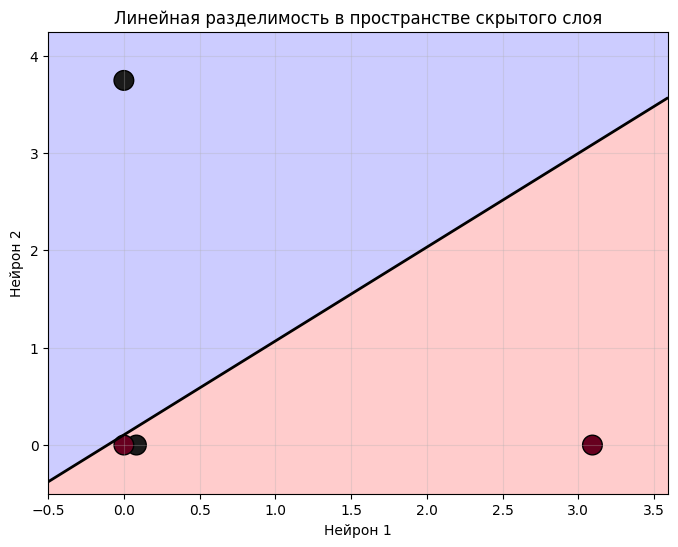

Accuracy линейного классификатора в новом пространстве: 0.75


In [ ]:
# Обучаем линейный классификатор на данных проекции
log_reg = LogisticRegression()
log_reg.fit(scatter_data, y_flat)

# Создаем сетку для отображения границы решения
xx, yy = np.meshgrid(
    np.linspace(scatter_data[:, 0].min() - 0.5, scatter_data[:, 0].max() + 0.5, 100),
    np.linspace(scatter_data[:, 1].min() - 0.5, scatter_data[:, 1].max() + 0.5, 100)
)
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Визуализация
plt.figure(figsize=(8, 6))

# Граница решения
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['red', 'blue'], alpha=0.2)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

# Точки данных
plt.scatter(scatter_data[:, 0], scatter_data[:, 1],
            c=y_flat, cmap='RdGy', edgecolors='k', s=200)

plt.title('Линейная разделимость в пространстве скрытого слоя')
plt.xlabel('Нейрон 1')
plt.ylabel('Нейрон 2')
plt.grid(True, alpha=0.3)
plt.show()

# Проверим accuracy линейного классификатора
accuracy = log_reg.score(scatter_data, y_flat)
print(f"Accuracy линейного классификатора в новом пространстве: {accuracy:.2f}")

Мы видим, что обучение линейного классификатора на данных проекции двух нейронов скрытого слоя не обеспечивает Accuracy = 1.

Скрытый слой с четырьмя нейронами создает 4D пространство, в котором классы XOR становятся линейно разделимыми. Однако при проецировании на первые два нейрона (2D) мы теряем часть информации, поэтому в этой проекции классы могут выглядеть неразделимыми.

Это наглядго иллюстрирует, как сети используют многомерные пространтва для решения нелинейных задач.

## Задача 7. Классификация датасета moon

### Постановка задачи

Выполнить классификацию датасета, созданного при помощи `make_moons`.

### Создание модели

Создадим класс ClassificationSolver, который будет воплощать сеть для решения задачи нелинейной классификации.

Архитекутра сети будет иметь следующий вид:

$$Input(2) → Hidden(n_1, ReLU) → Hidden(n_2, ReLU) → Output(1, Sigmoid)$$

Где:

- $n_1 , n_2$ - количество нейронов на каждом скрытом слое.

In [ ]:
class ClassificationSolver(torch.nn.Module):
    """
    Класс для решения задачи классификации

    Воплощает сеть с двумя скрытыми слоями.
    Подходит для решения задачи бинарной и многоклассовой классификации

    Параметры:
        input_size: int
            Количество входных нейронов
            По умолчанию: 2
        hidden_neurons_sizes: list
            Список с количеством нейронов для
            каждого слоя. По умолчанию [4, 8]
        num_classes: int
            Количество классов.
            По умолчанию 1 для бинарной классификации

    Атрибуты:
        fc1: torch.nn.Linear
            Первый скрытый слой
        act1: torch.nn.ReLU
            Функция активации первого слоя
        fc2: torch.nn.Linear
            Второй скрытый слой
        act2: torch.nn.ReLU
            Функция активации второго слоя
        fc3: torch.nn.Linear
            Выходной слой (возвращает логиты)

    Методы:
        forward()
            Прямой проход через модель
        predict()
            Делает предсказание

    """
    def __init__(self, input_size=2, hidden_neurons_sizes=[4, 8], num_classes=1):
        super(ClassificationSolver, self).__init__()

        self.input_size = input_size
        self.num_classes = num_classes

        self.fc1 = torch.nn.Linear(self.input_size, hidden_neurons_sizes[0])
        self.act1 = torch.nn.ReLU()

        self.fc2 = torch.nn.Linear(hidden_neurons_sizes[0], hidden_neurons_sizes[1])
        self.act2 = torch.nn.ReLU()

        self.fc3 = torch.nn.Linear(hidden_neurons_sizes[1], num_classes)


    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)

        return x

    def predict(self, x, threshold=0.5):
        """
        Делает предсказание

        Параметры:
            x: torch.Tensor
               Тензор координатами точек

            threshold: float
                Порог классификации. По умолчанию: 0.5
        Возвращает:
           -  Для num_classes=1: (y_pred, y_proba)
            y_pred: torch.Tensor - предсказания (0, 1)
            y_proba: torch.Tensor - вероятности класса 1
           -  Для num_classes>1: y_pred
            y_pred: torch.Tensor - предсказанные классы (0, 1, ..., num_classes-1)
        """
        with torch.no_grad():
            logits = self(x)

            if self.num_classes == 1:
                # Возвращаем вероятности
                y_proba = torch.sigmoid(logits)
                y_pred = (y_proba > threshold).float()
                return y_pred, y_proba
            else:
                # Многоклассовая классификация (возвращаем метки классов)
                y_proba = torch.softmax(logits, dim=1)
                y_pred = torch.argmax(y_proba, dim=1)
                return y_pred, y_proba[:, 1]

### Подбор лучших гиперпараметров

Попробуем решить задачу нелинейной классификации при помощи нашей сети на примере датасета `make_moons` с параметрами: `(n_samples=300, noise=0.1, random_state=SEED)`.

Для обучения будем использовать Adam. Попробуем задать разные `lr` при обучении, а также поэксперементируем с количеством нейронов на скрытых слоях.

In [ ]:
# Генерируем данные
X, y = make_moons(n_samples=300, noise=0.1, random_state=SEED)

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Нормализуем с использованием StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем в тензоры
X_train_torch = torch.FloatTensor(X_train_scaled)
y_train_torch = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_torch = torch.FloatTensor(X_test_scaled)
y_test_torch = torch.FloatTensor(y_test).reshape(-1, 1)

In [ ]:
def find_best_params(X_train, y_train, X_test, y_test, rates, increase_steps=4):
    """
    Подбирает значения lr, количества скрытых слоев
    при котором достигается максимальное значение accuracy_score и минимальный loss на test
    """
    best_accuracy = 0.0
    best_lr = None
    best_loss = float("inf")
    best_neurons = None

    # В цикле для каждого lr
    for r in tqdm.tqdm(rates):
        for step in range(1, increase_steps + 1):
            # Создаем модель с параметрами
            neurons = [4 * step, 8 * step]
            solver = ClassificationSolver(hidden_neurons_sizes=neurons)

            loss_func = torch.nn.BCEWithLogitsLoss()
            optimizer = torch.optim.Adam(solver.parameters(), lr=r)

            # Обучаем Adam в течение 1000 эпох
            for epoch in range(1000):
                optimizer.zero_grad()
                y_pred_learn = solver(X_train)
                loss = loss_func(y_pred_learn, y_train)
                loss.backward()
                optimizer.step()

            # Оцениваем accuracy и loss на train и test
            y_pred_train, y_proba_train = solver.predict(X_train)
            y_pred_test, y_proba_test = solver.predict(X_test)

            acc_train = accuracy_score(y_train.numpy(), y_pred_train.numpy())
            acc_test = accuracy_score(y_test.numpy(), y_pred_test.numpy())

            # Для loss используем BCEWithLogitsLoss (так как solver возвращает логиты)
            loss_train = loss_func(solver(X_train), y_train).item()
            loss_test = loss_func(solver(X_test), y_test).item()

            print(f"lr = {r:.2f}, neurons = {neurons}")
            print(f"  Accuracy_train = {acc_train:.4f}, Loss_train = {loss_train:.4f}")
            print(f"  Accuracy_test = {acc_test:.4f}, Loss_test = {loss_test:.4f}")
            print('-'*50)

            # Выбираем лучшие параметры по test
            if acc_test > best_accuracy:
                best_accuracy = acc_test
                best_lr = r
                best_loss = loss_test
                best_neurons = neurons
            elif acc_test == best_accuracy and loss_test < best_loss:
                best_lr = r
                best_neurons = neurons
                best_loss = loss_test

    print(f"\nЛучший lr: {best_lr:.2f}, нейроны: {best_neurons}")
    print(f"Accuracy_test: {best_accuracy:.4f}, Loss_test: {best_loss:.4f}")
    return best_lr, best_neurons

In [ ]:
# Разные значения lr
rates = np.arange(0.1, 0.55, 0.05)

best_lr, best_neurons = find_best_params(
    X_train_torch,
    y_train_torch,
    X_test_torch,
    y_test_torch,
    rates,
    increase_steps=4
    )

  0%|          | 0/9 [00:00<?, ?it/s]

lr = 0.10, neurons = [4, 8]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0011
--------------------------------------------------
lr = 0.10, neurons = [8, 16]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0005
--------------------------------------------------
lr = 0.10, neurons = [12, 24]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0002
--------------------------------------------------


 11%|█         | 1/9 [00:05<00:42,  5.34s/it]

lr = 0.10, neurons = [16, 32]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0001
--------------------------------------------------
lr = 0.15, neurons = [4, 8]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 0.9833, Loss_test = 0.0124
--------------------------------------------------
lr = 0.15, neurons = [8, 16]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0000
--------------------------------------------------
lr = 0.15, neurons = [12, 24]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 1.0000, Loss_test = 0.0002
--------------------------------------------------


 22%|██▏       | 2/9 [00:09<00:32,  4.62s/it]

...

lr = 0.40, neurons = [16, 32]
  Accuracy_train = 1.0000, Loss_train = 0.0001
  Accuracy_test = 0.9833, Loss_test = 0.0599
--------------------------------------------------
lr = 0.45, neurons = [4, 8]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 0.9833, Loss_test = 0.1359
--------------------------------------------------
lr = 0.45, neurons = [8, 16]
  Accuracy_train = 0.9792, Loss_train = 0.0502
  Accuracy_test = 0.9167, Loss_test = 0.2370
--------------------------------------------------
lr = 0.45, neurons = [12, 24]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 0.9833, Loss_test = 0.2947
--------------------------------------------------


 89%|████████▉ | 8/9 [00:36<00:04,  4.55s/it]

lr = 0.45, neurons = [16, 32]
  Accuracy_train = 0.9833, Loss_train = 0.0646
  Accuracy_test = 0.9333, Loss_test = 0.2077
--------------------------------------------------
lr = 0.50, neurons = [4, 8]
  Accuracy_train = 0.9000, Loss_train = 0.2236
  Accuracy_test = 0.8333, Loss_test = 0.3430
--------------------------------------------------
lr = 0.50, neurons = [8, 16]
  Accuracy_train = 0.9167, Loss_train = 0.1650
  Accuracy_test = 0.8667, Loss_test = 0.8796
--------------------------------------------------
lr = 0.50, neurons = [12, 24]
  Accuracy_train = 0.9125, Loss_train = 0.2104
  Accuracy_test = 0.9000, Loss_test = 0.5861
--------------------------------------------------


100%|██████████| 9/9 [00:40<00:00,  4.54s/it]

lr = 0.50, neurons = [16, 32]
  Accuracy_train = 1.0000, Loss_train = 0.0000
  Accuracy_test = 0.9833, Loss_test = 0.1477
--------------------------------------------------

Лучший lr: 0.20, нейроны: [16, 32]
Accuracy_test: 1.0000, Loss_test: 0.0000


### Обучение и визаулизация

Обучим нашу сеть с оптимальным `lr` и количеством скрытых нейронов на каждом слоев течение 1000 эпох, используя Adam, и визуализируем результат.

In [ ]:
# Инициализируем и обучаем модель с лучшими lr
solver = ClassificationSolver(hidden_neurons_sizes=best_neurons)
loss_func = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(solver.parameters(), lr=best_lr)

# Обучаем Adam в течение 1000 эпох
losses_history = losses_history = []

for epoch in range(1000):
    optimizer.zero_grad()
    y_pred_train = solver(X_train_torch)
    loss = loss_func(y_pred_train, y_train_torch)
    loss.backward()
    optimizer.step()

    y_pred_test = solver(X_test_torch)
    loss_test = loss_func(y_pred_test, y_test_torch)

    losses_history.append({'Epoch': epoch, 'loss_train': loss.item(), 'loss_test': loss_test.item()})

# Записываем динамику loss на train
losses_history = pd.DataFrame(losses_history)

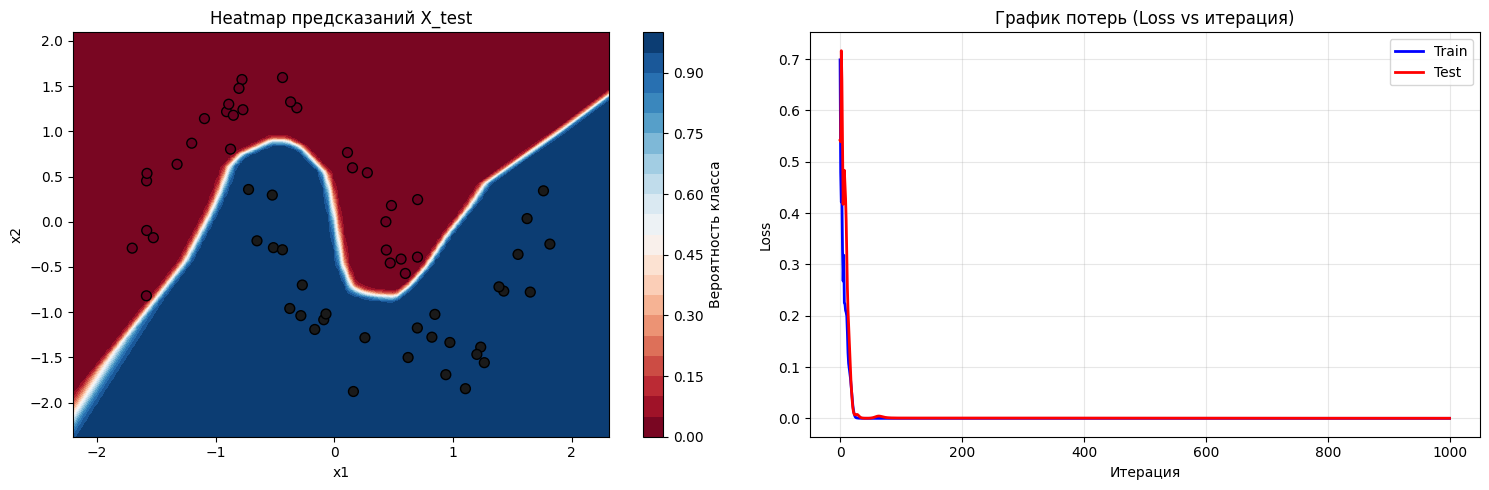

In [ ]:
plt.figure(figsize=(15, 5))

# Heatmap
plt.subplot(1, 2, 1)

# Определяем границы для сетки на основе данных
x_min, x_max = X_test_torch[:, 0].min() - 0.5, X_test_torch[:, 0].max() + 0.5
y_min, y_max = X_test_torch[:, 1].min() - 0.5, X_test_torch[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

_, grid_probs = solver.predict(grid)
grid_probs = grid_probs.numpy().reshape(xx.shape)

plt.contourf(xx, yy, grid_probs, levels=20, cmap='RdBu')
plt.colorbar(label='Вероятность класса')
plt.scatter(X_test_torch[:, 0], X_test_torch[:, 1], c=y_test_torch,
            edgecolors='k', s=50, cmap='RdGy')
plt.title('Heatmap предсказаний X_test')
plt.xlabel('x1')
plt.ylabel('x2')

# График потерь
plt.subplot(1, 2, 2)

plt.plot(losses_history['Epoch'], losses_history['loss_train'],
         label='Train', color='blue', linewidth=2)

plt.plot(losses_history['Epoch'], losses_history['loss_test'],
         label='Test', color='red', linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend()
plt.title("График потерь (Loss vs итерация)")
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [ ]:
# Оцениваем accuracy и loss
y_pred_class, y_proba = solver.predict(X_test_torch)
loss = loss_func(solver(X_test_torch), y_test_torch)
acc = accuracy_score(y_test_torch.numpy(), y_pred_class.numpy())

print(f"lr = {best_lr:.2f}, Accuracy = {acc:.4f}, Loss = {loss:.4f}")

lr = 0.20, Accuracy = 1.0000, Loss = 0.0001


Таким образом, при обучении в течение 1000 эпох при lr=0.4 удалось достигнуть accuracy=1.00 на тестовой выборке. При этом loss минимален (< 0.01).

Кривые loss vs итерация на `train` и `test` убывают практически идентично, что говорит об отсутствии переобучения.

Выбранная сеть с двумя скрытыми слоями и количеством нейронов на каждом скрытом слое 8 и 16 соотвественно успешно справилась с задачей классификации нелинейных данных, созданных при помощи `make_moons`.

---

# Задача 8. Комбинированная функция потерь (MSE + L1)

## Условие
Дана задача регрессии с 12 признаками. Нужно построить модель, которая минимизирует комбинированный loss: 70% MSE + 30% L1. Эта комбинация позволяет получить лучший баланс между сглаживанием и робастностью.

**Требования:**
1. Архитектура: 12 → 32 → 16 → 1.
2. Loss = 0.7 * MSE + 0.3 * MAE.
3. Оптимизатор: Adam (lr=0.01).
4. Количество эпох: 100.
5. Сравнить с чистым MSE и MAE.
6. Вывести: финальное RMSE и MAE на тесте.

## Теоретический минимум. Комбинированные Loss

### Определение
$$L = \alpha \cdot L_1(y, \hat{y}) + (1-\alpha) \cdot L_2(y, \hat{y})$$

Пример: $L = 0.7 \cdot \text{MSE} + 0.3 \cdot \text{MAE}$

### Интуиция
- Комбинируем преимущества разных функций потерь.
- MSE (70%): более сильно штрафует за большие ошибки.
- MAE (30%): добавляет робастность к выбросам.
- Выбор альфа зависит от конкретной задачи и данных.

### Когда использовать
- Когда нужна оптимизация по нескольким метрикам.
- Когда нужен компромисс между требованиями.
- Многозадачное обучение (multi-task learning).
- Когда данные содержат некоторые выбросы, но не критично.

### Подготовительный этап

Реализуем сеть для решения задачи регрессии с 12-ю признаками со следующей архитектурой:

$$Input(12) → ReLU(n1) → ReLU(n2) → Output(1)$$

Сеть имеет два скрытых слоя с $n_1$ и $n_2$ скрытми нейронами на каждом скрытом слое соответственно.

Поскольку сеть решает задачу регрессии в качестве функций активации на скрытых слоях применяется ReLU, а на выходном слое функция активации не применяется.



In [ ]:
class MultiDimRegSolver(torch.nn.Module):
    """
    Класс для решения задачи регрессии на нескольких признаках (>= 2).

    Воплощает сеть с двумя скрытыми слоями.

    Параметры:
        input_size: int
            Количество входных нейронов (признаков).
            По умолчанию 2.
        hidden_neurons_sizes: list
            Список с количеством нейронов для каждого слоя.
            По умолчанию [32, 16].

    Атрибуты:
        fc1: torch.nn.Linear
            Первый скрытый слой.
        act1: torch.nn.ReLU
            Функция активации первого слоя.
        fc2: torch.nn.Linear
            Второй скрытый слой.
        act2: torch.nn.ReLU
            Функция активации второго слоя.
        fc3: torch.nn.Linear
            Выходной слой (возвращает предсказанное значение).

    Методы:
        forward(x)
            Прямой проход через модель.
        predict(x)
            Делает предсказание (без вычисления градиентов).
    """
    def __init__(self, input_size=2, hidden_neurons_sizes=[32, 16]):
        super(MultiDimRegSolver, self).__init__()

        self.fc1 = torch.nn.Linear(input_size, hidden_neurons_sizes[0])
        self.act1 = torch.nn.ReLU()

        self.fc2 = torch.nn.Linear(hidden_neurons_sizes[0], hidden_neurons_sizes[1])
        self.act2 = torch.nn.ReLU()

        self.fc3 = torch.nn.Linear(hidden_neurons_sizes[1], 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        return x

    def predict(self, x):
        """
        Делает предсказание.

        Параметры:
            x: torch.Tensor
                Тензор с координатами точек.

        Возвращает:
            torch.Tensor
                Тензор с предсказаниями.
        """
        with torch.no_grad():  # Не вычисляем градиенты
            return self.forward(x)

Создадим также генератор данных для задачи регрессии.

In [ ]:
class RegressionDataGen():
    """
    Класс для генерации случайных n-мерных данных для задачи регрессии.

    Параметры:
        n_points : int
            Количество наблюдений.
        dim: int
            Размерность (количество признаков).
        random_state: int
            seed для обеспечения воспроизводимости.
        noise: float
            Случайный шум.
        nonlinearity: str
            Тип нелинейности ('poly', 'sin').
            Полиномиальная или синусоидальная.

    Атрибуты:
        X : np.array размером (n_points, dim)
            Массив признаков.
        y : np.array размером (n_points, 1)
            Массив результатов.
    """
    def __init__(self, n_points: int, dim: int,
                 random_state: int, noise: float = 1.0,
                 nonlinearity: str = 'poly'):
        self.n_points = n_points
        self.dim = dim
        self.random_state = random_state
        self.noise = noise
        self.nonlinearity = nonlinearity

    def generate_data(self):
        rng = np.random.RandomState(self.random_state)

        X = rng.randn(self.n_points, self.dim) * 2

        # Линейная компонента
        linear_weights = rng.randn(self.dim) * 0.5
        y = np.dot(X, linear_weights)

        # Добавляем нелинейность
        if self.nonlinearity == 'poly':
            # Полиномиальная: квадраты и произведения
            if self.dim >= 1:
                y += 0.5 * X[:, 0] ** 2
            if self.dim >= 2:
                y += 0.5 * X[:, 1] ** 2
            if self.dim >= 3:
                if self.dim > 3:
                    y += 0.3 * X[:, 2] * X[:, 3]
                else:
                    y += 0.3 * X[:, 2] ** 2

        elif self.nonlinearity == 'sin':
            # Синусоидальная
            for i in range(min(3, self.dim)):
                y += 1.5 * np.sin(X[:, i])

        # Добавляем шум
        y += rng.randn(self.n_points) * self.noise

        # Нормализуем
        y = (y - y.mean()) / y.std()

        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices].reshape(-1, 1)

        return X, y

Для нашей задачи будем применять комбинированную функцию потерь:

$$L = \alpha \cdot L_1(y, \hat{y}) + (1-\alpha) \cdot L_2(y, \hat{y})$$

Где:

- $L_1(y, \hat{y})$ - фунция MSE: $\frac{(y - \hat{y})^2}{n}$;
- $L_2(y, \hat{y})$ - фунция MAE: $\frac{|(y - \hat{y})|}{n}$
- $\alpha$ - коэффциент при MSE;
- $1 - \alpha$ - коэффициент при MAE соответственно.

In [ ]:
def combined_loss(pred, target, alpha=0.7):
    """
    Комбинированная функция потерь для решения задачи регрессии.

    L = alpha * MSE + (1 - alpha) * MAE

    Параметры:
        pred: torch.Tensor
            Тензор с предсказаниями.
        target: torch.Tensor
            Тензор с реальными значениями.
        alpha: float
            Вес MSE (по умолчанию 0.7).

    Возвращает:
        torch.Tensor
            Скалярное значение функции потерь.
    """
    # Дополнительная проверка размерности
    if pred.shape != target.shape:
        raise ValueError(
            f"Формы pred {pred.shape} и target {target.shape} не совпадают"
        )

    mse = torch.mean((pred - target) ** 2)
    mae = torch.mean(torch.abs(pred - target))

    return alpha * mse + (1 - alpha) * mae

### Решение
Приступим к решению задачи.
Создадим сеть с количеством нейронов на каждом скрытом слое: [32, 16] соответственно.
Сгенерируем данные для регрессии с 12-ю признаками.
Обучим Adam в течение 100 эпох при lr = 0.01. Рассчитаем динамику изменения комбинированной функции потерь, а также сравним с стандартными MSE и MAE

In [ ]:
# Создаем модель
multi_reg_model = MultiDimRegSolver(input_size=12)

In [ ]:
# Генерируем данные
gen = RegressionDataGen(n_points=10000, dim=12, random_state=SEED)
X_reg, y_reg = gen.generate_data()

# Разбиваем на train/test
X_tr_reg, X_tst_reg, y_tr_reg, y_tst_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Нормализуем с использованием StandardScaler
scaler = StandardScaler()
X_tr_scaled_reg = scaler.fit_transform(X_tr_reg)
X_tst_scaled_reg = scaler.transform(X_tst_reg)

# Преобразуем в тензоры
X_tr_torch_reg = torch.FloatTensor(X_tr_scaled_reg)
y_tr_torch_reg = torch.FloatTensor(y_tr_reg).reshape(-1, 1)
X_tst_torch_reg = torch.FloatTensor(X_tst_scaled_reg)
y_tst_torch_reg = torch.FloatTensor(y_tst_reg).reshape(-1, 1)

In [ ]:
# Обучаем модель с lr=0.01
loss_func = combined_loss
optimizer = torch.optim.Adam(multi_reg_model.parameters(), lr=0.01)

# Обучаем Adam в течение 100 эпох
history = []

for epoch in range(100):
    optimizer.zero_grad()
    y_pred_train_reg = multi_reg_model(X_tr_torch_reg)
    loss_train = loss_func(y_pred_train_reg, y_tr_torch_reg)
    mse_train = torch.mean((y_pred_train_reg - y_tr_torch_reg) ** 2)
    mae_train = torch.mean(torch.abs(y_pred_train_reg - y_tr_torch_reg))
    loss_train.backward()
    optimizer.step()

    y_pred_tst_reg = multi_reg_model.predict(X_tst_torch_reg)
    loss_test = loss_func(y_pred_tst_reg, y_tst_torch_reg)
    mse_test = torch.mean((y_pred_tst_reg - y_tst_torch_reg) ** 2)
    mae_test = torch.mean(torch.abs(y_pred_tst_reg - y_tst_torch_reg))

    history.append({
        'Epoch': epoch,
        'train_loss': loss_train.item(),
        'train_mse': mse_train.item(),
        'train_mae': mae_train.item(),
        'test_loss': loss_test.item(),
        'test_mse': mse_test.item(),
        'test_mae': mae_test.item()
    })

# Записываем динамику loss на train и loss, mse, mae на test
history_df = pd.DataFrame(history)

Визуализируем динамику изменения комбинированной функции потерь, MSE и MAE.

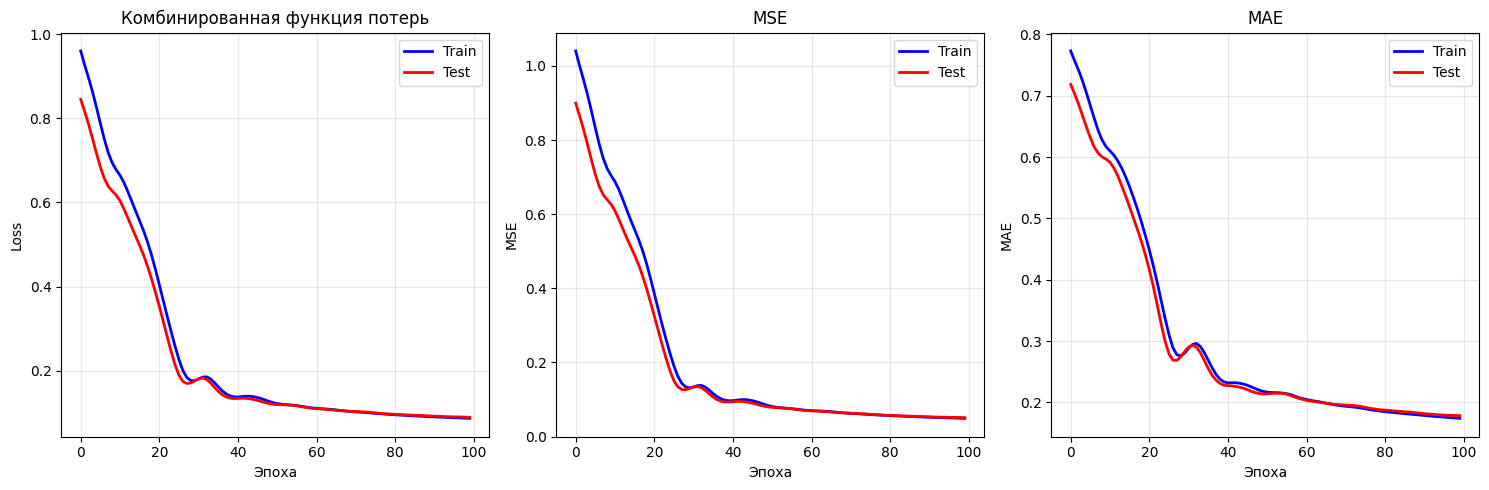

In [ ]:
plt.figure(figsize=(15, 5))

# График комбинированной loss
plt.subplot(1, 3, 1)
plt.plot(history_df['Epoch'], history_df['train_loss'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['Epoch'], history_df['test_loss'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("Комбинированная функция потерь")
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

# График MSE
plt.subplot(1, 3, 2)
plt.plot(history_df['Epoch'], history_df['train_mse'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['Epoch'], history_df['test_mse'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("MSE")
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()

# График MAE
plt.subplot(1, 3, 3)
plt.plot(history_df['Epoch'], history_df['train_mae'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['Epoch'], history_df['test_mae'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("MAE")
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

Кривые `train` и `test` для каждой метрики убывают парктически идентично, что указывает на отсутствие перобучения. Графики MSE и Комбинированной Loss очень похожи, что указывает на отсутствие выбросов в подаваемых данных. Это также указывет на то, что обе ошибки маленькие. Из-за этого комбинированный график повторяет кривую MSE, так как вклад MSE больше (0.7).

Сделаем финальное предсказание и оценим итоговые RMSE, MAE и $R^2$.

In [ ]:
# Оцениваем качество модели на тестовой выборке
y_pred = multi_reg_model.predict(X_tst_torch_reg)
loss = loss_func(y_pred, y_tst_torch_reg)

# Метрики качества
y_true_np = y_tst_torch_reg.numpy()
y_pred_np = y_pred.numpy()

rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
mae = mean_absolute_error(y_true_np, y_pred_np)
r2 = r2_score(y_true_np, y_pred_np)

print(f"Loss = {loss:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}, R^2 = {r2:.4f}")

Loss = 0.0893, RMSE = 0.2259, MAE = 0.1786, R^2 = 0.9445


Итоговые значения метрик говорят о хорошей предсказательной способности модели.
Значение $R^2 = 0.95$ означает, что модель объясняет 95% вариации целевой переменной, что свидетельствует о высокой точности предсказаний. Небольшая разница между RMSE и MAE указывает на отсутствие значительных выбросов в данных. Модель успешно справилась с задачей регрессии и может быть использована для предсказаний на новых данных.

---

# Задача 9. Классификация с дисбалансом (Weighted CrossEntropyLoss)

## Условие
Дана выборка из 500 примеров с бинарной классификацией, где 90% примеров принадлежат классу 0 (отрицательные), а 10% — классу 1 (положительные). Класс 1 недопредставлен. Нужно обучить модель, которая правильно предсказывает оба класса, несмотря на дисбаланс.

**Требования:**
1. Архитектура: 10 → 32 → 16 → 2.
2. Loss: CrossEntropyLoss с weight=class_weights.
3. Веса классов вычисляются как: weight = num_classes / count_per_class.
4. Оптимизатор: Adam (lr=0.01).
5. Количество эпох: 100.
6. Сравнить recall для каждого класса (с weight и без weight).

## Теоретический минимум: Weighted CrossEntropyLoss

### Определение
$$L = -\sum_{i=1}^{C} w_i \cdot y_i \log(p_i)$$

где:
- $w_i$ — вес класса; $i$
- Остальное — то же самое, что и CrossEntropyLoss.

### Расчет весов
Есть несколько способов:

1. **Inverse frequency:**
   $$w_i = \frac{N}{C \cdot n_i}$$
   где $N$ — всего примеров, $C$ — число классов, $n_i$ — число примеров класса $i$

2. **Простой обратный:**
   $$w_i = \frac{1}{n_i}$$

### Интуиция
- Редкие классы получают БОЛЬШИЕ веса (штраф за ошибку).
- Частые классы получают малые веса.
- Модель вынуждена уделять больше внимания редким классам.

### Когда использовать
- Дисбалансированные датасеты (часто в реальных данных).
- Когда редкий класс важнее (например, обнаружение редкой болезни).
- Когда нужна высокая recall для всех классов.

### Подготовительный этап

Для построения сети воспользуемся классом ClassificationSolver, созданным в задании 7. Сеть будет иметь следующую арихтектуру:

$$Input(10) → ReLU(32) → ReLU(16) → Output(2)$$

Дополнительно для выходного слоя будем применять  для активации.

Основное отличие от предыдущих задач классификации заключается в том, что в качестве функции активации выходного слоя будет применяться `SoftMax`, а не сигмоида, что позволит получить на выходе метки классов [0,1], а не вероятностную интерпретацию логитов. Именно поэтому выходной слой состоит из двух нейрогнов, а не из одного как в случае с сетью, где мы использовали сигмоиду.


In [ ]:
# Создаем модель
imbalanced_classificator = ClassificationSolver(
    input_size=10,
    hidden_neurons_sizes=[32, 16],
    num_classes=2
)

Создадим данные из 500 наблюдений и 10 признаков с несбалансированностью классов (90/10)при помощи  `make_classification` из `sklearn`.

In [ ]:
# Генерация данных
X_imbalanced, y_imbalanced = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=10,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    flip_y=0.02,
    class_sep=1.2,
    random_state=SEED
)

In [ ]:
# Разбиваем на train/test
X_tr_imbalanced, X_tst_imbalanced, y_tr_imbalanced, y_tst_imbalanced = train_test_split(
    X_imbalanced,
    y_imbalanced,
    test_size=0.2,
    random_state=SEED,
    stratify=y_imbalanced
)

# Нормализуем с использованием StandardScaler
scaler = StandardScaler()
X_tr_imbalanced_scaled = scaler.fit_transform(X_tr_imbalanced)
X_tst_imbalanced_scaled = scaler.transform(X_tst_imbalanced)

# Преобразуем в тензоры
X_tr_torch_imbalanced = torch.FloatTensor(X_tr_imbalanced_scaled)
y_tr_torch_imbalanced = torch.LongTensor(y_tr_imbalanced)
X_tst_torch_imbalanced = torch.FloatTensor(X_tst_imbalanced_scaled)
y_tst_torch_imbalanced = torch.LongTensor(y_tst_imbalanced)

### Решение задачи при заданных в задании гиперпараметрах

Обучим Adam в течение 100 эпох при lr=0.01. В качестве функции потерь будем использовать CrossEntropyLoss с weight=class_weights, чтобы учесть дисбаланс классов.

Для расчета весов воспользуемся способо простого обратного расчета весов:
   $$w_i = \frac{N}{C \cdot n_i}$$

Для оценки качества модели будем использовать `Recall` и `ROC-AUC`.

In [ ]:
# Вычисляем веса
unique, counts = np.unique(y_tr_torch_imbalanced, return_counts=True)
weights = len(unique) / counts
weights = torch.FloatTensor(weights)

print(f"Распределение классов в train: {dict(zip(unique, counts))}")
print(f"Веса классов: {weights}")

Распределение классов в train: {np.int64(0): np.int64(359), np.int64(1): np.int64(41)}
Веса классов: tensor([0.0056, 0.0488])


Более редкому классу были присвоены более высокие веса, что "штрафует" модель сильнее за ошибку на редком классе.

Обучим нашу модель. Дополнительно применим `L2-регуляризацию`, так как выборка небольшая и модель рискует переобучиться.

In [ ]:
# Функция потерь с весами
loss_func = torch.nn.CrossEntropyLoss(weight=weights)

# Создаем оптимизатор с weight_decay для борьбы с переобучением
optimizer = torch.optim.Adam(
    imbalanced_classificator.parameters(),
    lr=0.01,
    weight_decay=0.15
)

history = []

for epoch in range(101):
    # Обучаемся
    imbalanced_classificator.train()
    optimizer.zero_grad()

    logits_train = imbalanced_classificator(X_tr_torch_imbalanced)  # Получаем логиты
    loss_train = loss_func(logits_train, y_tr_torch_imbalanced)

    loss_train.backward()
    optimizer.step()

    # Переключаемся в режим оценки
    imbalanced_classificator.eval()
    with torch.no_grad():
        # Обучающая выборка
        train_preds, train_proba = imbalanced_classificator.predict(X_tr_torch_imbalanced)
        train_preds = train_preds.numpy()
        train_proba = train_proba.numpy()

        # Тестовая выборка
        logits_test = imbalanced_classificator(X_tst_torch_imbalanced)
        loss_test = loss_func(logits_test, y_tst_torch_imbalanced)
        test_preds, test_proba = imbalanced_classificator.predict(X_tst_torch_imbalanced)
        test_preds = test_preds.numpy()
        test_proba = test_proba.numpy()

    # Считаем метрики
    train_recall = recall_score(y_tr_imbalanced, train_preds, average=None)
    train_roc_auc = roc_auc_score(y_tr_imbalanced, train_proba)
    test_recall = recall_score(y_tst_imbalanced, test_preds, average=None)
    test_roc_auc = roc_auc_score(y_tst_imbalanced, test_proba)

    history.append({
        'epoch': epoch,
        'train_loss': loss_train.item(),
        'test_loss': loss_test.item(),
        'train_recall_0': train_recall[0],
        'train_recall_1': train_recall[1],
        'test_recall_0': test_recall[0],
        'test_recall_1': test_recall[1],
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc
    })

    # Выводим промежуточные результаты для отладки
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={loss_train.item():.4f}, "
              f"Test Loss={loss_test.item():.4f}, "
              f"Test Recall_1={test_recall[1]:.4f}, "
              f"Test Recall_0={test_recall[0]:.4f}")

# Создаем DataFrame с метриками
history_df = pd.DataFrame(history)

Epoch 0: Train Loss=0.7092, Test Loss=0.6699, Test Recall_1=0.7000, Test Recall_0=0.6889
Epoch 20: Train Loss=0.4371, Test Loss=0.4084, Test Recall_1=0.9000, Test Recall_0=0.8556
Epoch 40: Train Loss=0.3323, Test Loss=0.3206, Test Recall_1=0.9000, Test Recall_0=0.9111
Epoch 60: Train Loss=0.3577, Test Loss=0.3384, Test Recall_1=0.9000, Test Recall_0=0.9111
Epoch 80: Train Loss=0.3605, Test Loss=0.3393, Test Recall_1=0.9000, Test Recall_0=0.9000
Epoch 100: Train Loss=0.3624, Test Loss=0.3411, Test Recall_1=0.9000, Test Recall_0=0.9000


Мы видим, как `loss` постепенно уменьшается, а Recall для редкого класса не опускается ниже 0.1. Это говорит о том, что признаки переобучения отсутсствуют и модель демонстрирует хорошие результаты по выявлению редкого класса.

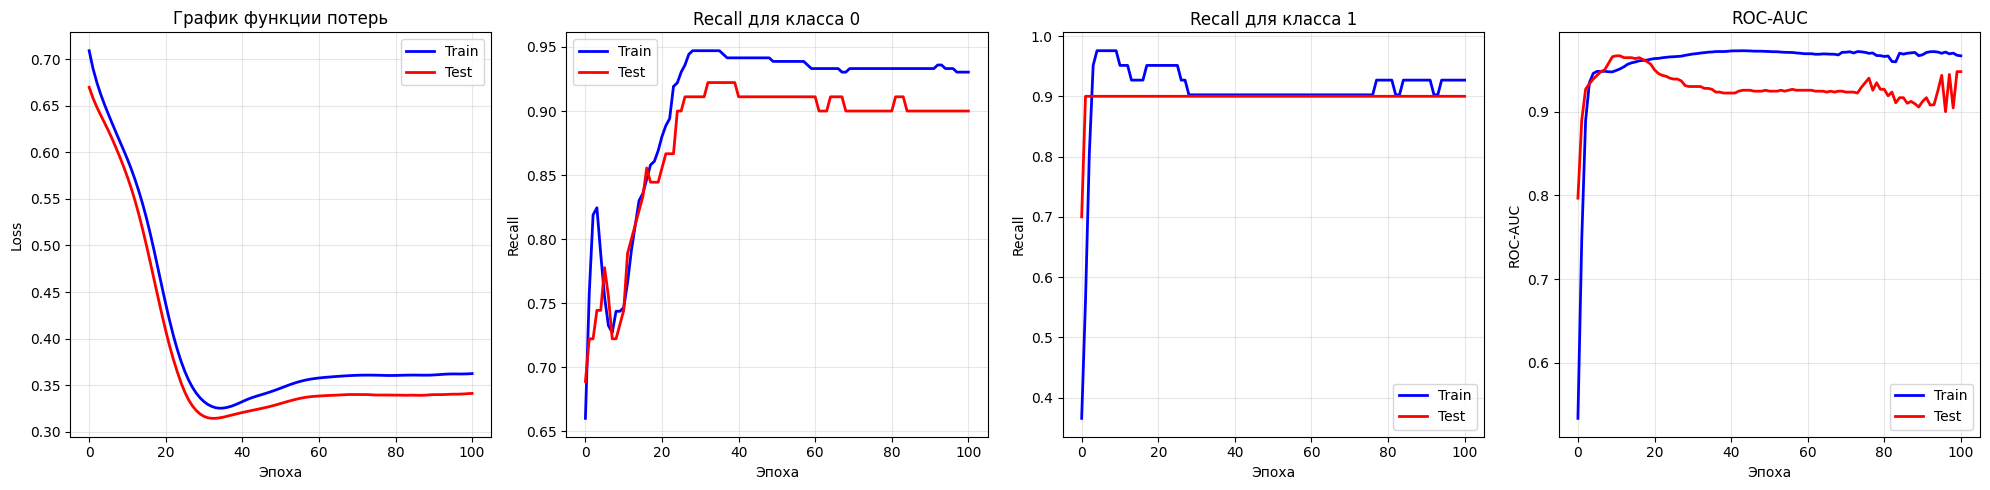

In [ ]:
# Создаем DataFrame с метриками
history_df = pd.DataFrame(history)

plt.figure(figsize=(20, 5))

# График loss
plt.subplot(1, 4, 1)
plt.plot(history_df['epoch'], history_df['train_loss'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['epoch'], history_df['test_loss'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("График функции потерь")
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

# График для Recall класса 0
plt.subplot(1, 4, 2)
plt.plot(history_df['epoch'], history_df['train_recall_0'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['epoch'], history_df['test_recall_0'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("Recall для класса 0")
plt.xlabel('Эпоха')
plt.ylabel('Recall')
plt.legend()

# График для Recall класса 1
plt.subplot(1, 4, 3)
plt.plot(history_df['epoch'], history_df['train_recall_1'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['epoch'], history_df['test_recall_1'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("Recall для класса 1")
plt.xlabel('Эпоха')
plt.ylabel('Recall')
plt.legend()

# График ROC-AUC
plt.subplot(1, 4, 4)
plt.plot(history_df['epoch'], history_df['train_roc_auc'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_df['epoch'], history_df['test_roc_auc'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("ROC-AUC")
plt.xlabel('Эпоха')
plt.ylabel('ROC-AUC')
plt.legend()

plt.tight_layout()
plt.show()

Графики указывают на отсутствие явного переобучения (о чем свидетельствует отсутствие разрыва между loss-кривыми `train` и `test`, небольшой разрыв между ROC-AUC для `train` и `test`). Разрыв между `Recall` для обоих классов небольшой, что говорит о том, что модель хорошо выявляет принадлежность к обоим классам. Кривая `ROC-AUC` для `test`

### Решение задачи без применения параметра `weight` в функции потерь

Теперь посмотрим, как поведет себя модель при отсутствии параметра `weight` в функции потерь.

In [ ]:
# Создаем модель
no_weights_classificator = ClassificationSolver(
    input_size=10,
    hidden_neurons_sizes=[32, 16],
    num_classes=2
)

In [ ]:
# Функция потерь без весов
loss_func = torch.nn.CrossEntropyLoss()

# Создаем оптимизатор с weight_decay для борьбы с переобучением
optimizer = torch.optim.Adam(
    no_weights_classificator.parameters(),
    lr=0.01,
    weight_decay=0.15
)

history_no_weights = []

for epoch in range(101):
    # Обучаемся
    no_weights_classificator.train()
    optimizer.zero_grad()

    logits_train = no_weights_classificator(X_tr_torch_imbalanced)  # Получаем логиты
    loss_train = loss_func(logits_train, y_tr_torch_imbalanced)

    loss_train.backward()
    optimizer.step()

    # Переключаемся в режим оценки
    no_weights_classificator.eval()
    with torch.no_grad():
        # Обучающая выборка
        train_preds, train_proba = no_weights_classificator.predict(X_tr_torch_imbalanced)
        train_preds = train_preds.numpy()
        train_proba = train_proba.numpy()

        # Тестовая выборка
        logits_test = no_weights_classificator(X_tst_torch_imbalanced)
        loss_test = loss_func(logits_test, y_tst_torch_imbalanced)
        test_preds, test_proba = no_weights_classificator.predict(X_tst_torch_imbalanced)
        test_preds = test_preds.numpy()
        test_proba = test_proba.numpy()

    # Считаем метрики
    train_recall = recall_score(y_tr_imbalanced, train_preds, average=None)
    train_roc_auc = roc_auc_score(y_tr_imbalanced, train_proba)
    test_recall = recall_score(y_tst_imbalanced, test_preds, average=None)
    test_roc_auc = roc_auc_score(y_tst_imbalanced, test_proba)

    history_no_weights.append({
        'epoch': epoch,
        'train_loss': loss_train.item(),
        'test_loss': loss_test.item(),
        'train_recall_0': train_recall[0],
        'train_recall_1': train_recall[1],
        'test_recall_0': test_recall[0],
        'test_recall_1': test_recall[1],
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc
    })

    # Выводим промежуточные результаты для отладки
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={loss_train.item():.4f}, "
              f"Test Loss={loss_test.item():.4f}, "
              f"Test Recall_1={test_recall[1]:.4f}, "
              f"Test Recall_0={test_recall[0]:.4f}")

Epoch 0: Train Loss=0.7846, Test Loss=0.7411, Test Recall_1=1.0000, Test Recall_0=0.0222
Epoch 20: Train Loss=0.3212, Test Loss=0.3064, Test Recall_1=0.0000, Test Recall_0=1.0000
Epoch 40: Train Loss=0.2859, Test Loss=0.2851, Test Recall_1=0.0000, Test Recall_0=1.0000
Epoch 60: Train Loss=0.2709, Test Loss=0.2701, Test Recall_1=0.0000, Test Recall_0=1.0000
Epoch 80: Train Loss=0.2783, Test Loss=0.2770, Test Recall_1=0.0000, Test Recall_0=1.0000
Epoch 100: Train Loss=0.2831, Test Loss=0.2818, Test Recall_1=0.0000, Test Recall_0=1.0000


При отсутствии параметра `weight` модель совершенно перестает учитывать редкий класс и начинает выявлять только частый класс. Таким образом, уже к 20-й эпохе значения `Recall` для редкого класса становится равным 0. При этом для класса 0 `Recall` равен 1.

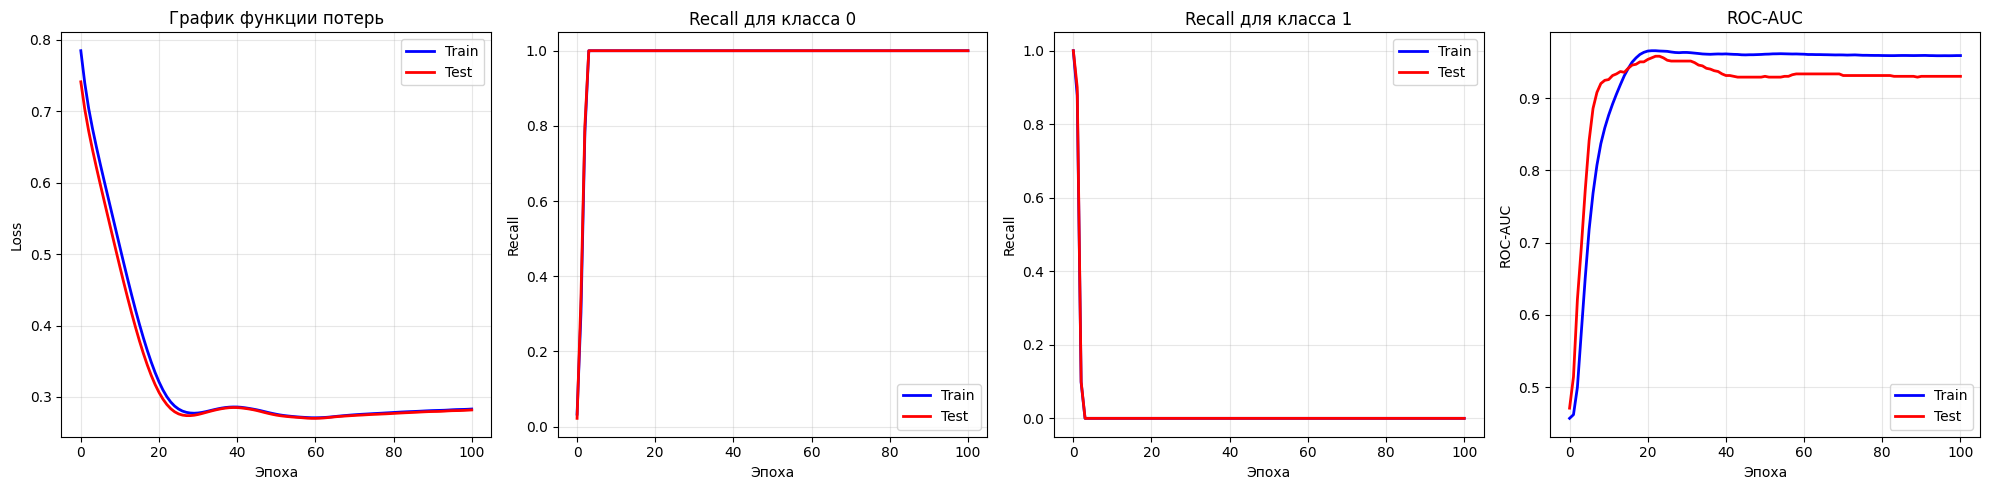

In [ ]:
# Создаем DataFrame с метриками
history_no_weights_df = pd.DataFrame(history_no_weights)

plt.figure(figsize=(20, 5))

# График loss
plt.subplot(1, 4, 1)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['train_loss'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['test_loss'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("График функции потерь")
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

# График для Recall класса 0
plt.subplot(1, 4, 2)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['train_recall_0'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['test_recall_0'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("Recall для класса 0")
plt.xlabel('Эпоха')
plt.ylabel('Recall')
plt.legend()

# График для Recall класса 1
plt.subplot(1, 4, 3)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['train_recall_1'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['test_recall_1'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("Recall для класса 1")
plt.xlabel('Эпоха')
plt.ylabel('Recall')
plt.legend()

# График ROC-AUC
plt.subplot(1, 4, 4)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['train_roc_auc'],
         label='Train', color='blue', linewidth=2)
plt.plot(history_no_weights_df['epoch'], history_no_weights_df['test_roc_auc'],
         label='Test', color='red', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title("ROC-AUC")
plt.xlabel('Эпоха')
plt.ylabel('ROC-AUC')
plt.legend()

plt.tight_layout()
plt.show()

Графики также показывают отсутствие переобучения, однако видно, что модель совершенно не выявляет объекты редкого класса, полностью переключаяся на выявление класса 0.

Таким образом, на примере данной модели была продемонстрирована важность учета несбалансированности классов и необходимость оцеки метрик качества (Recall) на примере обоих классов.

---

# ИТОГОВАЯ ТАБЛИЦА: КОГДА ИСПОЛЬЗОВАТЬ КАКУЮ LOSS ФУНКЦИЮ

| Задача | Loss Function | Когда использовать | Примеры |
|--------|---------------|--------------------|----------|
| Многоклассовая классификация (C≥2) | **CrossEntropyLoss** | Взаимно исключающие классы | Классификация изображений (MNIST), распознавание животных |
| Бинарная классификация | **BCEWithLogitsLoss** | Двуклассовая задача, один выход | Обнаружение спама, предсказание CTR |
| Регрессия с выбросами | **HuberLoss** | Данные содержат аномалии | Финансовые прогнозы, анализ датчиков |
| Многокритериальная задача | **Комбинированная** (α·L1 + (1-α)·L2) | Нужен компромисс между метриками | Multi-task learning, балансировка требований |
| Дисбалансированная классификация | **Weighted CrossEntropyLoss** | Классы недопредставлены неравномерно | Обнаружение редких болезней, fraud detection |

---

# ПОЛЕЗНЫЕ СОВЕТЫ

1. **Всегда нормализуйте признаки** (StandardScaler, MinMaxScaler).
2. **Проверяйте распределение классов** перед выбором loss.
3. **Используйте validation set** для контроля overfitting.
4. **Экспериментируйте с hyperparameters** (lr, weights, alpha).
5. **Визуализируйте learning curves** для диагностики.
6. **Не забывайте про evaluation metrics** (Accuracy, Precision, Recall, F1, AUC).

---